#Name: Aliza Lama
#Student ID: 240853

#1. MCP Neurons Implementation
#AND Gate

In [3]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements MCP Neuron for AND operation.
    """
    assert len(X1) == len(X2)
    state_neuron = []
    for x1, x2 in zip(X1, X2):
        s = x1 + x2
        if s >= T:  # Threshold check
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron

# Sample usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2
result = MCP_Neurons_AND(X1, X2, T)
print(f"AND output: {result}")  # [0, 0, 0, 1]

AND output: [0, 0, 0, 1]


#OR Gate


In [4]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements MCP Neuron for OR operation.
    """
    assert len(X1) == len(X2)
    state_neuron = []
    for x1, x2 in zip(X1, X2):
        s = x1 + x2
        if s >= T:  # Threshold check
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron

# Sample usage
T = 1
result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR output: {result_or}")  # [0, 1, 1, 1]

OR output: [0, 1, 1, 1]


In [ ]:
#2. Limitations of MCP Neurons

#Can only solve linearly separable problems (e.g., AND, OR).

#Cannot solve non-linear problems like XOR.

#Fixed threshold – cannot adapt or learn from data.

#No mechanism for error correction or learning.

#Very basic, works only for small-scale binary inputs.

In [ ]:
#3. XOR with MCP Neurons

#Direct MCP neuron cannot implement XOR because XOR is not linearly separable.

#We could use a combination of MCP neurons:

#Use two neurons to compute A AND NOT B and NOT A AND B.

#Feed their outputs to another neuron with OR logic.

#Pseudo-logic:

#XOR = (A AND NOT B) OR (NOT A AND B)

In [5]:
#4. Perceptron Implementation
#Decision Function
import numpy as np

def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias
    y_pred_all = np.where(z >= 0, 1, 0)  # Step function
    return y_pred_all

In [7]:
#Training Function (Perceptron Learning Algorithm)
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        total_correct = 0
        for xi, target in zip(X, y):
            linear_output = np.dot(xi, weights) + bias
            y_pred = 1 if linear_output >= 0 else 0
            error = target - y_pred
            weights += learning_rate * error * xi
            bias += learning_rate * error
            if error == 0:
                total_correct += 1
    accuracy = total_correct / len(y)
    return weights, bias, accuracy

In [8]:
#(AND Gate)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])
weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=10)
print("Weights:", weights)
print("Bias:", bias)
print("Accuracy:", accuracy)

Weights: [0.2 0.1]
Bias: -0.20000000000000004
Accuracy: 1.0


#Task 2: Perceptron for 0 vs 1 classification

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI&ML/data/mnist_0_and_1.csv")

# Features and labels
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values  # 0 or 1

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


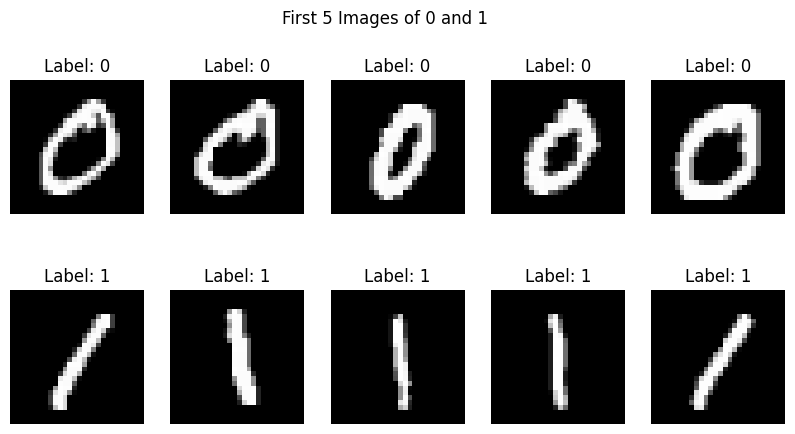

In [11]:
#Visualize the Dataset
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1")
plt.show()

In [12]:
#Initialize Weights and Bias
weights = np.zeros(X.shape[1])  # 784 weights, one per pixel
bias = 0
learning_rate = 0.1
epochs = 100

In [ ]:
#Answer the Questions:
#Question 3: What does the weights array represent?
#Each element of weights represents how important a pixel is for classifying the image as 0 or 1.

#Question 4: Why initialize weights to zero? Effect on training?

#Zero initialization is simple, the perceptron learning algorithm will adjust weights during training.

#It might start slow, but since the perceptron is guaranteed to converge for linearly separable data (0 vs 1), it will still learn correctly.

In [13]:
#Decision Function
def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias
    y_pred_all = np.where(z >= 0, 1, 0)  # step function
    return y_pred_all

In [14]:
#Perceptron Learning Algorithm
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        total_correct = 0
        for xi, target in zip(X, y):
            output = np.dot(xi, weights) + bias  # net input
            y_pred = 1 if output >= 0 else 0
            error = target - y_pred

            # Update weights and bias if prediction wrong
            weights += learning_rate * error * xi
            bias += learning_rate * error

            if error == 0:
                total_correct += 1

    accuracy = total_correct / len(y)
    return weights, bias, accuracy

In [15]:
#Train the Perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print(f"Final Accuracy: {accuracy:.4f}")

Final Accuracy: 1.0000


In [16]:
#Visualize Misclassified Images
y_pred = decision_function(X, weights, bias)
misclassified_idx = np.where(y_pred != y)[0]

# Question 8 & 9:
# - misclassified_idx stores indices where prediction != true label.
# - If "All images were correctly classified!" → perceptron perfectly separates 0 vs 1.

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

All images were correctly classified!


In [17]:
#4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST 3 and 5 subset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI&ML/data/mnist_3_and_5.csv")  # Adjust the path if needed

# Features and labels
X = df_3_5.drop(columns=["label"]).values  # 784 pixels per image
y = df_3_5["label"].values  # 3 or 5

# Convert labels to binary: 3 -> 0, 5 -> 1 (for perceptron)
y = np.where(y == 3, 0, 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


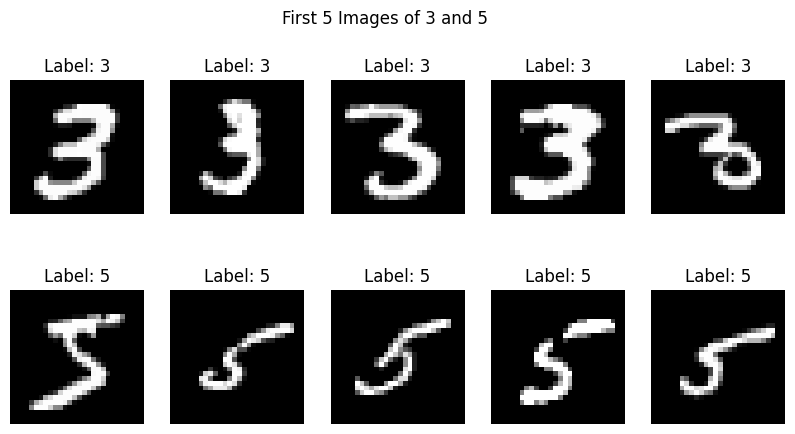

In [18]:
#Visualize the Dataset
images_3 = X[y == 0]  # original 3s
images_5 = X[y == 1]  # original 5s

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5")
plt.show()

In [20]:
#Initialize Weights and Bias
weights = np.zeros(X.shape[1])  # 784 weights
bias = 0
learning_rate = 0.1
epochs = 100

In [21]:
#Decision Function
def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias
    y_pred_all = np.where(z >= 0, 1, 0)  # step function
    return y_pred_all

In [22]:
#Perceptron Training Algorithm
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        total_correct = 0
        for xi, target in zip(X, y):
            output = np.dot(xi, weights) + bias
            y_pred = 1 if output >= 0 else 0
            error = target - y_pred

            # Update weights and bias if misclassified
            weights += learning_rate * error * xi
            bias += learning_rate * error

            if error == 0:
                total_correct += 1

    accuracy = total_correct / len(y)
    return weights, bias, accuracy

In [24]:
#Train the Perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print(f"Final Accuracy: {accuracy:.4f}")

Final Accuracy: 0.9858


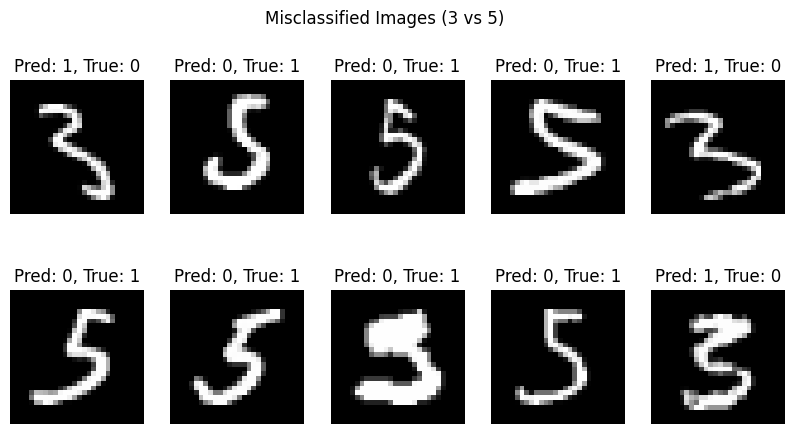

In [25]:
#Visualize Misclassified Images
y_pred = decision_function(X, weights, bias)
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # show 10 misclassified
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")